# Compare NetCDF Coordinates

This notebook reads two NetCDF files and checks if their latitude and longitude coordinate arrays are the same.

## 1. Import Required Libraries

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import uxarray as ux

import warnings
warnings.filterwarnings("ignore")


## 2. Load NetCDF Files

Specify the paths to your two NetCDF files and load them.

In [2]:
# --- CONFIGURATION ---
indir = "/pscratch/sd/k/ksa/simulation/DP-SCREAM/cases/test_regrid_cpu_dpxx_RCE_dx1km"
dpscream_file = f"{indir}/run/test_regrid_cpu_dpxx_RCE_dx1km.hist.INSTANT.nmins_x5.2000-01-01-00000.nc"
grid_file = "/global/cfs/cdirs/wcm_shr/DP-SCREAM/remap/scrip_DPSCREAM_RCE_dx1km_600x600km.nc"

remap_xy = "XY"

remapped_file_01    = f"{indir}/run/test_regrid_cpu_dpxx_RCE_dx1km.hist.INSTANT.nmins_x5.2000-01-01-00000_PINACLES_{remap_xy}_dx1km_600x600km.nc"

remapped_file_02    = f"{indir}/post_processed_output/2D/test_regrid_cpu_dpxx_RCE_dx1km_2D_T_2m.nc"

# --- LOAD DATA ---
ds_dp = ux.open_dataset(grid_file, dpscream_file)
ds_remapped_01 = xr.open_dataset(remapped_file_01)
ds_remapped_02 = xr.open_dataset(remapped_file_02)

In [3]:
# 1. Extract Arrays
invarname = "T_2m"
intime = 11
vartest = {}

vartest["dp"] = ds_dp[invarname].isel(time=intime)
vartest["remapped_01"] = ds_remapped_01[invarname].isel(time=intime).values
vartest["remapped_02"] = ds_remapped_02[invarname].isel(time=intime).values



In [4]:
lat01_remapped = ds_remapped_01['lat'].values
lon01_remapped = ds_remapped_01['lon'].values

y_remapped = ds_remapped_02['y'].values
x_remapped = ds_remapped_02['x'].values

lat02_remapped = ds_remapped_02['lat'].values
lon02_remapped = ds_remapped_02['lon'].values



In [12]:
arr = vartest["remapped_02"]
n_nan = np.sum(np.isnan(arr))
n_inf = np.sum(np.isinf(arr))

In [14]:
fill_value = 3.402824e+33
n_fill = np.sum(arr >= 1e+30)

print(f"Array shape : {arr.shape}")
print(f"NaN count : {n_nan}")
print(f"Inf count : {n_inf}")
print(f"Values >= 1e30 (fill-value-like) : {n_fill}")
print(f"Min value : {np.nanmin(arr):.4f}")
print(f"Max value : {np.nanmax(arr):.4f}")

Array shape : (600, 600)
NaN count : 0
Inf count : 0
Values >= 1e30 (fill-value-like) : 0
Min value : 297.0080
Max value : 297.0896


In [11]:
vartest["remapped_02"]

(600, 600)

In [5]:
print(y_remapped[0:5])
print(x_remapped[0:5])

[ 750. 2250. 3750. 5250. 6750.]
[ 750. 2250. 3750. 5250. 6750.]


In [6]:
cmin = 296.9
cmax = 297.1

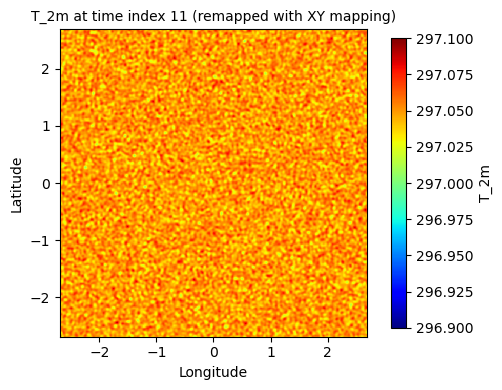

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

pcm = ax.pcolormesh(lon01_remapped, lat01_remapped, vartest["remapped_01"] ,cmap='jet',vmin = cmin, vmax = cmax )  #,vmin = 296, vmax = 299
_=ax.set_xlabel('Longitude')
_=ax.set_ylabel('Latitude')
_=fig.colorbar(pcm, ax=ax, label=invarname, fraction=0.03)

_=ax.set_title(f"{invarname} at time index {intime} (remapped with {remap_xy} mapping)", fontsize='medium')


_=ax.set_aspect('equal')
plt.tight_layout()
plt.show()

fig.clear() #this does free memory: https://stackoverflow.com/a/55834853/20647995
plt.close(fig)

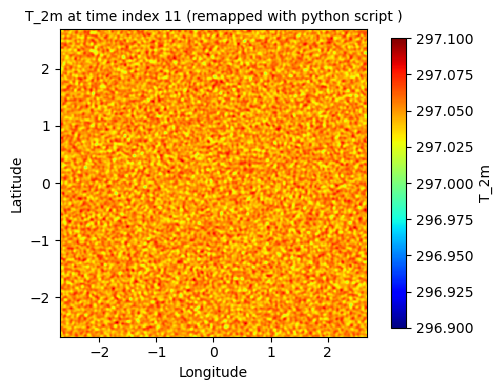

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

pcm=ax.pcolormesh(lon02_remapped,lat02_remapped,vartest["remapped_02"],cmap='jet',vmin = cmin, vmax = cmax )  #,vmin = 296, vmax = 299
_=fig.colorbar(pcm, ax=ax, label=invarname, fraction=0.03)
_=ax.set_title(f"{invarname} at time index {intime} (remapped with python script )", fontsize='medium')
_=ax.set_xlabel('Longitude')
_=ax.set_ylabel('Latitude')
_=ax.set_aspect('equal')
plt.tight_layout()
plt.show()

fig.clear() #this does free memory: https://stackoverflow.com/a/55834853/20647995
plt.close(fig)

In [21]:
idiff =  vartest["remapped_02"].T -  vartest["remapped_01"]
dcmin = -0.01
dcmax = 0.01


In [22]:
np.nanmin(idiff)
np.nanmax(idiff)

np.float32(0.0)

np.float32(0.0)

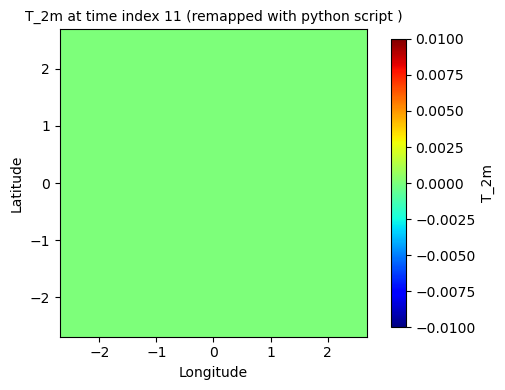

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))

pcm=ax.pcolormesh(lon_remapped,lat_remapped,idiff,cmap='jet',vmin = dcmin, vmax = dcmax )  #,vmin = 296, vmax = 299
_=fig.colorbar(pcm, ax=ax, label=invarname, fraction=0.03)
_=ax.set_title(f"{invarname} at time index {intime} (remapped with python script )", fontsize='medium')
_=ax.set_xlabel('Longitude')
_=ax.set_ylabel('Latitude')
_=ax.set_aspect('equal')
plt.tight_layout()
plt.show()

fig.clear() #this does free memory: https://stackoverflow.com/a/55834853/20647995
plt.close(fig)

In [32]:
np.max(idiff)
np.min(idiff)

np.float32(0.0)

np.float32(0.0)

### compared to be the plot by uxarray directory on the raw output
often messes up jupyter notebook and other cells stop showing the figure

:Image   [x,y]   (x_y T_2m)
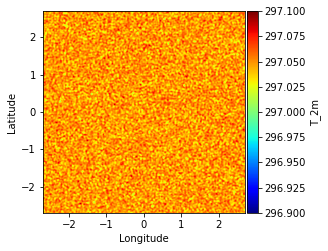

In [26]:
# Create figure and axis
#fig, ax = plt.subplots(figsize=(10, 8))

# Plot on the specified axis
vartest["dp"] .plot(backend='matplotlib', cmap='jet', aspect=1, clim=(cmin,cmax))



# plt.tight_layout()
# plt.show()

### raw output plotting with uxarray

In [ ]:
# Check dimensions
print(f"lon shape: {lon_remapped.shape}")
print(f"lat shape: {lat_remapped.shape}")
print(f"var shape: {var_remapped.shape}")
print(f"var dims: {var_remapped.dims}")